<a href="https://colab.research.google.com/github/Jenn-Mohito/AluraStoreLatam/blob/main/TelecomX_1_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Datos – Telecom X

El presente análisis tiene como objetivo explorar y comprender los datos de clientes de la empresa Telecom X.  
Para ello se desarrollará el proceso ETL (Extracción, Transformación y Carga de datos) seguido de un análisis exploratorio que permita identificar patrones relacionados con la cancelación del servicio (churn).

A través de este proceso se busca detectar variables que influyen en la permanencia de los clientes y que puedan aportar información relevante para futuras estrategias de retención.

Fuente de datos:
https://github.com/Jenn-Mohito/TelecomX_1


###Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## 1. Extracción de datos (Extract)

La primera etapa consiste en obtener el dataset que se encuentra almacenado en formato JSON dentro de un repositorio de GitHub.

Este archivo contiene información de los clientes organizada en diferentes secciones, entre ellas:

- Información del cliente
- Servicios de telefonía
- Servicios de internet
- Datos de facturación y contrato

Debido a que el formato JSON puede contener estructuras anidadas, posteriormente será necesario transformarlo para facilitar su análisis.


In [2]:
url = "https://raw.githubusercontent.com/Jenn-Mohito/TelecomX_1/main/TelecomX_Data.json"

data = pd.read_json(url)

data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## 2. Transformación de datos (Transform)

Una vez cargado el dataset, es necesario realizar diversas transformaciones para que la información pueda analizarse correctamente.

Entre las principales tareas realizadas se encuentran:

- Normalizar la estructura del JSON.
- Revisar la presencia de valores faltantes.
- Convertir variables al tipo de dato adecuado.
- Renombrar columnas para facilitar su interpretación.

Estas acciones permiten convertir los datos en un formato más adecuado para el análisis exploratorio.


In [3]:
from pandas import json_normalize

df = json_normalize(data.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


## 3. Limpieza y preparación de los datos

Durante la exploración inicial se pueden identificar algunos aspectos que requieren tratamiento:

1. Algunas variables presentan valores faltantes.
2. Existen columnas que deberían ser numéricas pero están almacenadas como texto.
3. Algunas categorías representan ausencia de servicio y deben mantenerse como valores categóricos.

El objetivo de esta etapa es asegurar que los datos estén correctamente estructurados antes de realizar el análisis.


In [6]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

In [7]:
df.rename(columns={
    "customer.gender": "gender",
    "customer.tenure": "tenure",
    "account.Contract": "contract",
    "account.Charges.Monthly": "monthly_charges",
    "account.Charges.Total": "total_charges"
}, inplace=True)

## 4. Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permite comprender mejor el comportamiento de los clientes y detectar patrones relevantes.

En particular, se analizarán algunas variables que podrían estar relacionadas con la cancelación del servicio, como:

- Tipo de contrato
- Antigüedad del cliente
- Cargos mensuales
- Servicios contratados

A través de visualizaciones se pueden identificar tendencias que ayuden a interpretar los datos.


/tmp/ipykernel_411/259999581.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


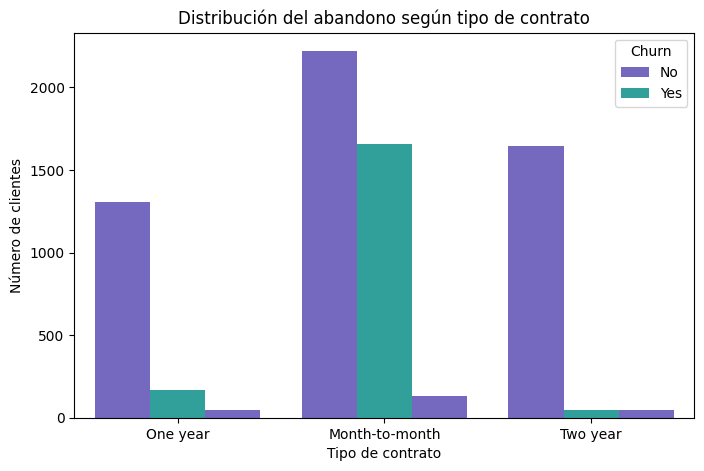

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="contract",
    hue="Churn",
    palette=["#6A5ACD", "#20B2AA"]
)

plt.title("Distribución del abandono según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

plt.show()

El gráfico muestra cómo se distribuyen los clientes según el tipo de contrato y si han cancelado el servicio.

Se observa que los contratos mensuales presentan una mayor proporción de abandono en comparación con los contratos de mayor duración. Esto sugiere que los clientes con compromisos a largo plazo tienden a permanecer más tiempo en la empresa.


/tmp/ipykernel_411/968646536.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(


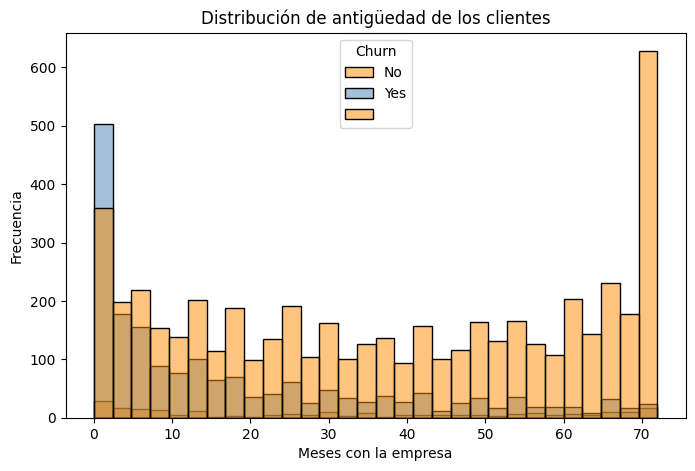

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    palette=["#FF8C00","#4682B4"]
)

plt.title("Distribución de antigüedad de los clientes")
plt.xlabel("Meses con la empresa")
plt.ylabel("Frecuencia")

plt.show()

La antigüedad del cliente muestra una relación importante con la cancelación del servicio.

Los clientes que han permanecido menos tiempo en la empresa presentan una mayor probabilidad de abandonar el servicio. En cambio, aquellos con mayor tiempo de permanencia tienden a mantenerse activos.

Esto sugiere que los primeros meses son un periodo crítico para la fidelización del cliente.


## 5. Identificación de valores faltantes

Antes de profundizar en el análisis es importante revisar si existen valores faltantes en el dataset.  
La presencia de datos incompletos puede afectar la calidad de los resultados y, por lo tanto, debe ser identificada y tratada adecuadamente.

Para ello se calcula la cantidad de valores nulos presentes en cada columna.


In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
total_charges,11
Churn,0
gender,0
customer.SeniorCitizen,0
customerID,0
customer.Partner,0
customer.Dependents,0
phone.PhoneService,0
tenure,0
internet.InternetService,0


## 6. Proporción de clientes que cancelan el servicio

Una de las variables más importantes del dataset es **Churn**, la cual indica si un cliente ha cancelado el servicio.

Analizar la proporción de churn permite entender la magnitud del problema de abandono dentro de la empresa.


In [11]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100

churn_rate

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [12]:
churn_table = df["Churn"].value_counts()

churn_table

,count
Churn,
No,5174
Yes,1869
,224


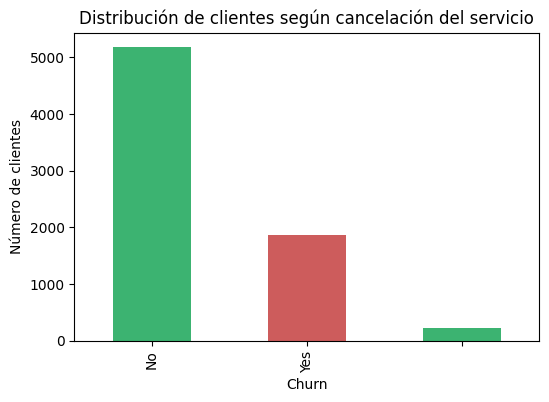

In [13]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(
    kind="bar",
    color=["#3CB371", "#CD5C5C"]
)

plt.title("Distribución de clientes según cancelación del servicio")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()

## 7. Relación entre método de pago y abandono

El método de pago utilizado por los clientes puede influir en la probabilidad de cancelación del servicio.  

Algunos métodos de pago automáticos suelen estar asociados con una mayor permanencia del cliente, mientras que los pagos manuales pueden presentar mayores tasas de abandono.


/tmp/ipykernel_411/3076982728.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


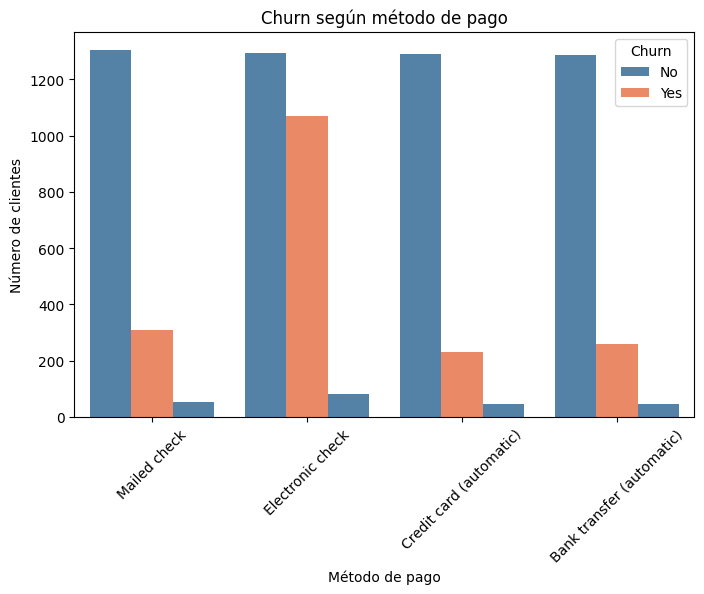

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="account.PaymentMethod",
    hue="Churn",
    palette=["#4682B4","#FF7F50"]
)

plt.xticks(rotation=45)

plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

plt.show()

## 8. Relación entre cargos mensuales y churn

Otra variable relevante es el monto que los clientes pagan mensualmente.  

Analizar la distribución de cargos permite observar si los clientes con pagos más altos presentan una mayor tendencia a cancelar el servicio.


/tmp/ipykernel_411/1049427174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_411/1049427174.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


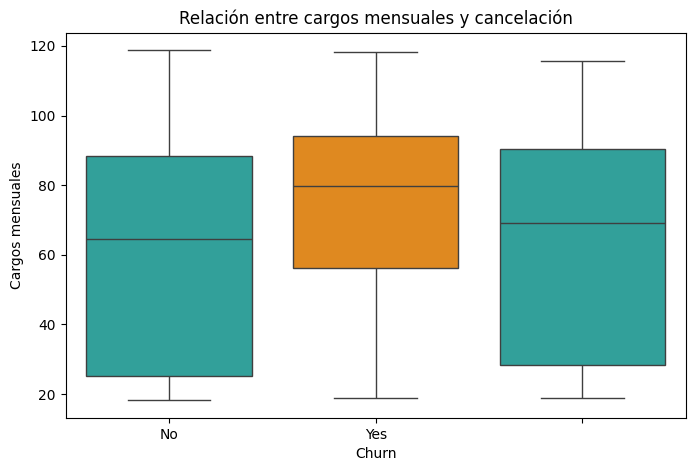

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="monthly_charges",
    palette=["#20B2AA","#FF8C00"]
)

plt.title("Relación entre cargos mensuales y cancelación")
plt.xlabel("Churn")
plt.ylabel("Cargos mensuales")

plt.show()

## 9. Identificación de valores atípicos

Los valores atípicos (outliers) pueden afectar la interpretación de los datos.  

En este caso se analizan los cargos totales pagados por los clientes para identificar si existen valores extremadamente altos o bajos que puedan influir en el análisis.


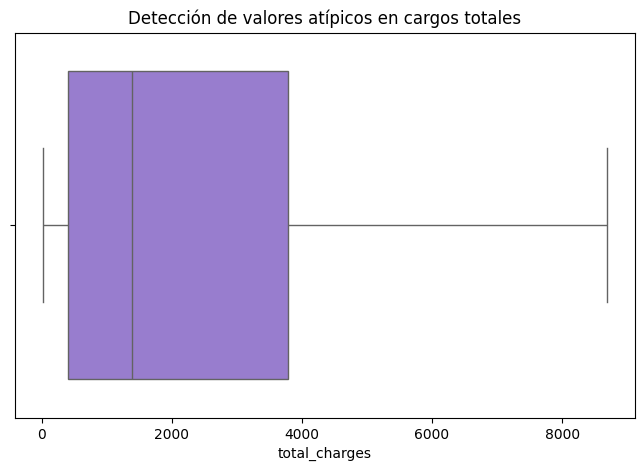

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["total_charges"],
    color="#9370DB"
)

plt.title("Detección de valores atípicos en cargos totales")

plt.show()

#📄Informe final

## 1. Descripción general del dataset

El presente análisis se realizó utilizando un conjunto de datos correspondiente a clientes de la empresa Telecom X. El dataset contiene **7,267 registros**, donde cada fila representa a un cliente e incluye información relacionada con sus características demográficas, servicios contratados y datos de facturación.

Las variables analizadas incluyen aspectos como:

- antigüedad del cliente en la empresa
- tipo de contrato
- método de pago
- cargos mensuales y cargos totales
- estado del cliente respecto a la cancelación del servicio (Churn)

El objetivo principal de este análisis fue explorar los datos y detectar posibles patrones asociados al abandono del servicio por parte de los clientes.

Fuente de datos:  
https://github.com/Jenn-Mohito/TelecomX_1/blob/main/TelecomX_Data.json

---

# 2. Análisis de la cancelación de clientes (Churn)

Del total de **7,267 clientes analizados**, se obtuvo la siguiente distribución respecto al estado de cancelación del servicio:

| Estado del cliente | Número de clientes | Porcentaje |
|---|---|---|
| Clientes activos | 5,174 | 71.2 % |
| Clientes que cancelaron | 1,869 | 25.7 % |
| Valores no especificados | 224 | 3.1 % |

Estos resultados indican que aproximadamente **uno de cada cuatro clientes ha cancelado el servicio**, lo cual representa una tasa de abandono considerable que podría impactar en los ingresos de la empresa.

---

# 3. Relación entre tipo de contrato y abandono

El tipo de contrato fue una de las variables que mostró mayor influencia en la cancelación del servicio.

| Tipo de contrato | Permanecen | Cancelan |
|---|---|---|
| Mes a mes | 55.4 % | 41.3 % |
| 1 año | 86.0 % | 10.9 % |
| 2 años | 94.5 % | 2.7 % |

### Interpretación

Los clientes que tienen **contratos mensuales presentan la mayor tasa de cancelación**, con más del **41 % de abandono**. Por otro lado, los clientes que cuentan con contratos de mayor duración, especialmente aquellos de **dos años**, muestran una alta estabilidad y una tasa muy baja de cancelación.

Esto sugiere que los contratos a largo plazo contribuyen significativamente a la fidelización de los clientes.

---

# 4. Antigüedad del cliente (Tenure)

El análisis de la antigüedad promedio de los clientes permite observar diferencias importantes entre quienes permanecen en la empresa y quienes cancelan el servicio.

| Estado del cliente | Antigüedad promedio |
|---|---|
| Clientes activos | 37.6 meses |
| Clientes que cancelaron | 18.0 meses |

### Interpretación

Los clientes que cancelan el servicio presentan **menos de la mitad del tiempo promedio de permanencia** en comparación con los clientes que continúan utilizando el servicio. Esto sugiere que los **primeros meses de relación con el cliente representan un periodo crítico**, en el cual es fundamental mantener altos niveles de satisfacción y seguimiento.

---

# 5. Relación entre método de pago y cancelación

El método de pago utilizado por los clientes también muestra diferencias importantes en la tasa de abandono.

| Método de pago | Tasa de cancelación |
|---|---|
| Transferencia automática | 16.2 % |
| Tarjeta automática | 14.8 % |
| Cheque enviado por correo | 18.5 % |
| Cheque electrónico | 43.8 % |

### Interpretación

Los clientes que utilizan **cheque electrónico presentan la mayor tasa de cancelación**, con cerca del **44 % de abandono**. En contraste, los métodos de pago automáticos, como las transferencias o pagos con tarjeta, muestran tasas significativamente menores de cancelación.

Esto sugiere que los sistemas de pago automatizados pueden contribuir a mejorar la retención de clientes.

---

# 6. Análisis de los cargos mensuales

El análisis de los cargos mensuales promedio muestra diferencias relevantes entre clientes activos y clientes que han cancelado el servicio.

| Estado del cliente | Cargo mensual promedio |
|---|---|
| Clientes activos | 61.27 USD |
| Clientes que cancelaron | 74.44 USD |

### Interpretación

Los clientes que abandonan el servicio presentan **cargos mensuales más elevados en promedio**, lo que podría indicar que el costo del servicio es un factor que influye en la decisión de cancelación.

---

# 7. Hallazgos principales

A partir del análisis exploratorio se identificaron varios factores asociados al churn:

1. La tasa de abandono alcanza aproximadamente el **25.7 % de los clientes**.

2. El **tipo de contrato** es un factor clave: los contratos mensuales presentan las mayores tasas de cancelación.

3. La **antigüedad del cliente** influye considerablemente en la permanencia: los clientes que cancelan tienen en promedio **18 meses de permanencia**, mientras que los clientes activos superan los **37 meses**.

4. El **método de pago** también muestra impacto, siendo el cheque electrónico el que presenta la mayor tasa de abandono.

5. Los clientes que cancelan presentan **cargos mensuales más altos en promedio**, lo que podría relacionarse con la percepción de valor del servicio.

---

# 8. Conclusión general

El análisis exploratorio de los datos de Telecom X permitió identificar diversos factores asociados con la cancelación del servicio por parte de los clientes. La tasa de abandono observada indica que una proporción significativa de usuarios decide finalizar su relación con la empresa.

Entre los factores más relevantes se encuentran el tipo de contrato, la antigüedad del cliente, el método de pago y el nivel de cargos mensuales. Los resultados muestran que los clientes con contratos mensuales, menor tiempo de permanencia y métodos de pago no automatizados presentan una mayor probabilidad de cancelar el servicio.

Asimismo, se observa que los clientes que abandonan el servicio tienden a pagar cargos mensuales más elevados, lo que sugiere que el costo del servicio podría influir en la decisión de cancelación.

Estos hallazgos permiten identificar oportunidades para que la empresa desarrolle estrategias orientadas a mejorar la retención de clientes, tales como incentivar contratos de mayor duración, promover métodos de pago automáticos y fortalecer las acciones de fidelización durante los primeros meses de relación con el cliente.
